In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/katarina74/ml_lessons/main/lesson_2/data/techparams_train.csv")
X = df.drop(["target", "index"], axis=1)
y = df[["target"]]

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
sns.set();

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [24]:
def shaple_value(X, Y, random_state=14, test_size=0.2):
    def subsets(S):
        sets = []
        len_S = len(S)
        for i in range( 1 << len_S ):
            subset = [ S[ bit ] for bit in range( len_S ) if i & ( 1 << bit ) ]
            sets.append( subset )
        return sets

    train_X, test_X, train_y, test_y = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    res = []
    fi = {}
    N_with_i = train_X.columns
    for future in N_with_i:
        N_out_i = list(set(N_with_i) - {future})
        for S in subsets(list(N_out_i))[1:]:
            model_with_i = LinearRegression()
            model_out_i = LinearRegression()
            model_out_i.fit(train_X[S], train_y)
            model_with_i.fit(train_X[list(set(S) | {future})], train_y)
            y_pred_with_i = model_with_i.predict(test_X[list(set(S) | {future})])
            y_pred_out_i = model_out_i.predict(test_X[S])
            res.append((math.factorial(len(S))*math.factorial(len(N_with_i)-len(S)-1))/math.factorial(len(N_with_i))*((((y_pred_with_i-y_pred_out_i))**2).mean()))
        fi.update({future:float(np.sum(res))})
        res = []
    return fi, sns.barplot(x=list(fi.values()), y=list(fi.keys()))

d:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


({'back-suspension': 0.784937835215552,
  'battery-capacity': 143.83687028619235,
  'charge-time': 205.0218383943743,
  'compression': 30.177223339155987,
  'consumption-mixed': 205.90248055716006,
  'cylinders-order': 3024.510956645423,
  'cylinders-value': 7693.512169668567,
  'engine-feeding': 34.18260266109211,
  'engine-start': 1643.161941325362},
 <Axes: >)

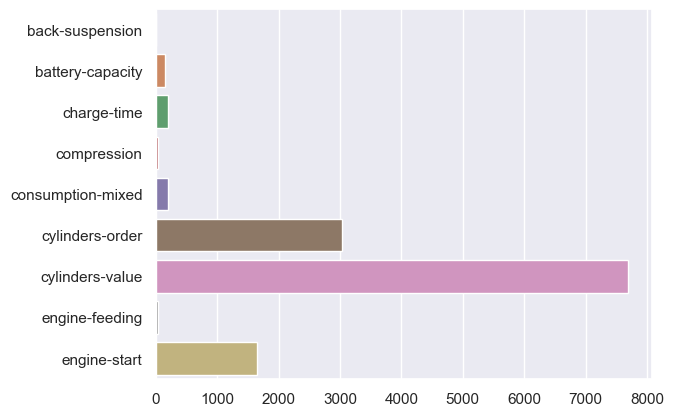

In [60]:
shaple_value(X[X.columns[:9]], y)

In [57]:
def permutation(X, Y, random_state=14, test_size=0.2):
    train_X, test_X, train_y, test_y = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    full_model = LinearRegression()
    full_model.fit(train_X, train_y)
    full_model_predict = full_model.predict(test_X)
    res = {}

    for future in X.columns:
        X_perm = X.copy()
        X_perm.loc[:, future] = pd.Series(np.random.permutation(X_perm[future]))
        train_X, test_X, train_y, test_y = train_test_split(X_perm, Y, test_size=test_size, random_state=random_state)
        shuffle_model_predict = full_model.predict(test_X)
        res.update({future:((full_model_predict-shuffle_model_predict)**2).mean()})
    return res, sns.barplot(x=list(res.values()), y=list(res.keys()))

d:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


({'back-suspension': 1.3130367173378124,
  'battery-capacity': 685.2072559333471,
  'charge-time': 1474.267336639047,
  'compression': 1044.2892717523587,
  'consumption-mixed': 23.554603616032807,
  'cylinders-order': 1.3871134827431304,
  'cylinders-value': 21223.15810567916,
  'engine-feeding': 376.02972455425913,
  'engine-start': 2721.2588260879597,
  'engine-stop': 167.49232923118393,
  'engine-type': 2993.454743809257,
  'gear-type': 1165.3108140650074,
  'luxury': 105.1404950040788,
  'max-speed': 801.3405513205364,
  'power-electro-kw': 31.814912562738183,
  'supply-system': 7.9769624545293185,
  'valves': 119.66876969604327,
  'valvetrain': 10.689810136069543,
  'weight': 747.6321175582264,
  'configurations_auto-premiere': 1631.8205513464907,
  'configurations_back-wheel-base': 668.2959268816928,
  'configurations_front-brake': 167.84268828042914,
  'configurations_safety-rating': 51.31666513858382,
  'configurations_seats': 5520.186854756771,
  'configurations_tank-volume':

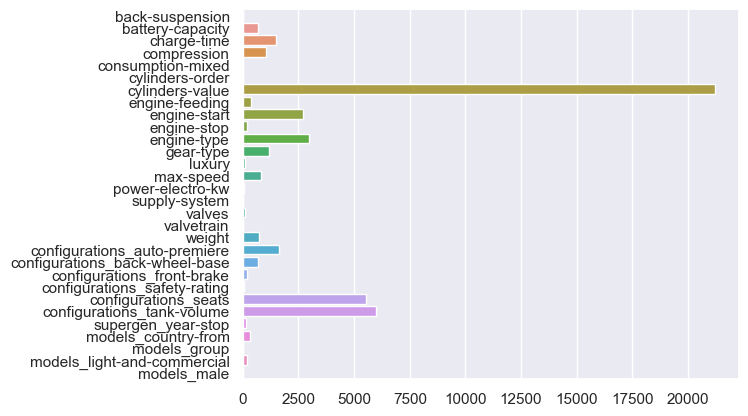

In [59]:
permutation(X, y)